# 23 · 정제 모델 하이퍼파라미터 탐색

**한 줄 답:** 지금 단계의 하이퍼파라미터 탐색은 “최고 AUC 찾기”가 아니라 “흔들림이 작은 설정 찾기”다. 표본은 95대, 양성은 12대뿐이라 넓은 탐색은 과적합을 부른다.

**타깃:** `later_active` = 첫 관측 후 10분~24시간 안에 의도적 행동이 1회 이상 있는가.

**입력:** `22_refined_retention_feature_model.ipynb`에서 만든 refined feature table. beta_A/B 표시 기기는 제외되어 있고, A/B 효과는 보지 않는다.

**사전 기준:**

- 후보 설정은 repeated CV AUC가 기본 `refined_behavior(C=0.2, l2, balanced)` 이상이어야 한다.
- PR-AUC가 기본값의 95% 미만이면 AUC가 높아도 보류한다.
- top 30% recall이 80% 이상이어야 한다.
- nested CV에서 AUC가 0.85 이상이면 채택 후보, 0.75~0.85면 보류, 0.75 미만이면 기각.
- XGBoost/LightGBM은 이번 게이트에서 쓰지 않는다. 양성 12대라 트리 부스팅은 비교보다 과적합 위험이 크다.

## 1. 데이터와 함수

In [1]:
from pathlib import Path
import json
import os, sys
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
SRC = ROOT / 'ml/reports/g5_refined_retention_model_2026-09-15/refined_retention_feature_table.csv'
BASE_METRICS = ROOT / 'ml/reports/g5_refined_retention_model_2026-09-15/refined_model_metrics.csv'
OUT = ROOT / 'ml/reports/g5_refined_hyperparam_search_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

def bootstrap_ci(y, p, metric, n_boot=3000, seed=23):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(y[s])) < 2:
            continue
        vals.append(metric(y[s], p[s]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def prep_model(feature_cols, C, penalty, class_weight):
    return Pipeline([
        ('prep', ColumnTransformer([
            ('num', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
            ]), feature_cols),
        ], remainder='drop')),
        ('clf', LogisticRegression(
            C=C,
            penalty=penalty,
            class_weight=class_weight,
            solver='liblinear',
            max_iter=1000,
            random_state=23,
        )),
    ])

def evaluate_oof(df, y, feature_cols, C, penalty, class_weight, n_repeats=30, seed=23):
    cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=n_repeats, random_state=seed)
    pred_sum = np.zeros(len(y), dtype=float)
    pred_count = np.zeros(len(y), dtype=float)
    X = df[feature_cols]
    for tr, te in cv.split(X, y):
        model = prep_model(feature_cols, C, penalty, class_weight)
        model.fit(X.iloc[tr], y[tr])
        pred_sum[te] += model.predict_proba(X.iloc[te])[:, 1]
        pred_count[te] += 1
    return pred_sum / pred_count

def score_predictions(y, p):
    cutoff = np.quantile(p, 0.70)
    flagged = p >= cutoff
    return {
        'auc': float(roc_auc_score(y, p)),
        'pr_auc': float(average_precision_score(y, p)),
        'top30_cutoff': float(cutoff),
        'top30_flagged': int(flagged.sum()),
        'top30_precision': float(y[flagged].mean()),
        'top30_recall': float(y[flagged].sum() / y.sum()),
        'top30_balanced_acc': float(balanced_accuracy_score(y, flagged.astype(int))),
    }

def inner_select(train_df, train_y, grid, n_splits=3):
    rows = []
    X_idx = np.arange(len(train_y))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=230)
    for cfg in grid:
        pred = np.zeros(len(train_y), dtype=float)
        counts = np.zeros(len(train_y), dtype=float)
        X = train_df[cfg['feature_cols']]
        for tr, va in cv.split(X_idx, train_y):
            model = prep_model(cfg['feature_cols'], cfg['C'], cfg['penalty'], cfg['class_weight'])
            model.fit(X.iloc[tr], train_y[tr])
            pred[va] += model.predict_proba(X.iloc[va])[:, 1]
            counts[va] += 1
        scores = score_predictions(train_y, pred / counts)
        rows.append({**cfg, **scores})
    ranked = pd.DataFrame(rows).sort_values(['auc', 'pr_auc', 'top30_recall'], ascending=False)
    return ranked.iloc[0].to_dict(), ranked


In [2]:
d = pd.read_csv(SRC)
d['y'] = d.later_active.astype(bool).astype(int)
d['is_toss_observed'] = (d.channel_segment == '토스 관측').astype(int)
d['is_mobile'] = (d.device == 'mobile').astype(int)
d['is_south_korea'] = (d.country_group == 'South Korea').astype(int)

count_cols = [c for c in d.columns if c.startswith('early_') and c.endswith('_events')]
for col in count_cols + ['early_tracked_events', 'early_actions', 'early_action_kinds', 'early_area_count', 'early_event_name_count']:
    d[f'log_{col}'] = np.log1p(d[col])

assert len(d) == 95
assert int(d.y.sum()) == 12
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0

behavior_core = [
    'log_early_tracked_events',
    'log_early_actions',
    'deliberate_share',
    'log_early_action_kinds',
    'log_early_area_count',
    'log_early_event_name_count',
    'log_early_ga_auto_events',
    'log_early_entry_auth_events',
    'log_early_connect_ok_events',
    'log_early_connect_fail_events',
    'log_early_other_tracking_events',
    'ga_auto_share',
    'entry_auth_share',
    'other_tracking_share',
    'log_early_nature_events',
    'log_early_fishing_sea_events',
    'log_early_quest_social_events',
    'log_early_craft_home_events',
    'log_early_advanced_events',
]
lean_behavior = [
    'log_early_tracked_events',
    'log_early_actions',
    'deliberate_share',
    'log_early_action_kinds',
    'log_early_area_count',
    'log_early_event_name_count',
    'log_early_ga_auto_events',
    'log_early_entry_auth_events',
    'log_early_connect_fail_events',
    'log_early_connect_ok_events',
    'log_early_nature_events',
    'log_early_fishing_sea_events',
    'log_early_advanced_events',
]
named_events = [
    'log_early_chop_tree_events',
    'log_early_mine_ore_events',
    'log_early_npc_talk_events',
    'log_early_tutorial_step_events',
    'log_early_quest_offered_events',
    'log_early_churn_score_events',
    'log_early_session_summary_events',
    'log_early_session_time_events',
    'log_early_econ_tx_events',
    'log_early_zone_enter_events',
]

feature_sets = {
    'lean_behavior': lean_behavior,
    'refined_behavior': behavior_core,
    'refined_behavior_plus_named_events': behavior_core + named_events,
}

y = d.y.to_numpy()
base = pd.read_csv(BASE_METRICS)
base_refined = base.loc[base.model.eq('refined_behavior')].iloc[0].to_dict()
display(pd.DataFrame([base_refined]))


,model,kind,features,auc,auc_ci_low,auc_ci_high,pr_auc,balanced_acc_at_top_30pct
0,refined_behavior,cv_logistic,19,0.914659,0.766234,0.995294,0.8219,0.8499


## 2. 좁은 grid search

탐색 범위는 L1/L2와 regularization 강도만 둔다. class weight는 `balanced`와 완화형 2개만 비교한다.

In [3]:
pos_weight = float((y == 0).sum() / (y == 1).sum())
class_weight_grid = {
    'balanced': 'balanced',
    'pos_4': {0: 1.0, 1: 4.0},
    'pos_7': {0: 1.0, 1: round(pos_weight, 2)},
}
C_grid = [0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
penalty_grid = ['l1', 'l2']

grid = []
for fs_name, cols in feature_sets.items():
    for C, penalty, cw_name in product(C_grid, penalty_grid, class_weight_grid):
        grid.append({
            'feature_set': fs_name,
            'feature_cols': cols,
            'n_features': len(cols),
            'C': C,
            'penalty': penalty,
            'class_weight_name': cw_name,
            'class_weight': class_weight_grid[cw_name],
        })

rows = []
preds = {}
for cfg in grid:
    p = evaluate_oof(d, y, cfg['feature_cols'], cfg['C'], cfg['penalty'], cfg['class_weight'], n_repeats=30)
    scores = score_predictions(y, p)
    rows.append({k: v for k, v in cfg.items() if k not in ['feature_cols', 'class_weight']} | scores)
    key = f"{cfg['feature_set']}|C={cfg['C']}|{cfg['penalty']}|{cfg['class_weight_name']}"
    preds[key] = p

grid_results = pd.DataFrame(rows).sort_values(['auc', 'pr_auc', 'top30_recall'], ascending=False)
grid_results.to_csv(OUT / 'logistic_grid_results.csv', index=False)
display(grid_results.head(20))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value an

...

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,feature_set,n_features,C,penalty,class_weight_name,auc,pr_auc,top30_cutoff,top30_flagged,top30_precision,top30_recall,top30_balanced_acc
94,refined_behavior_plus_named_events,29,0.20,l2,pos_4,0.934739,0.874508,0.232102,29,0.37931,0.916667,0.8499
88,refined_behavior_plus_named_events,29,0.10,l2,pos_4,0.933735,0.865045,0.289703,29,0.37931,0.916667,0.8499
82,refined_behavior_plus_named_events,29,0.05,l2,pos_4,0.933735,0.847075,0.348211,29,0.37931,0.916667,0.8499
89,refined_behavior_plus_named_events,29,0.10,l2,pos_7,0.932731,0.874861,0.314234,29,0.37931,0.916667,0.8499
93,refined_behavior_plus_named_events,29,0.20,l2,balanced,0.932731,0.874861,0.306191,29,0.37931,0.916667,0.8499
100,refined_behavior_plus_named_events,29,0.50,l2,pos_4,0.931727,0.868721,0.165825,29,0.37931,0.916667,0.8499
4,lean_behavior,13,0.03,l2,pos_4,0.931727,0.848070,0.420568,29,0.37931,0.916667,0.8499
87,refined_behavior_plus_named_events,29,0.10,l2,balanced,0.929719,0.866116,0.371677,29,0.37931,0.916667,0.8499
95,refined_behavior_plus_named_events,29,0.20,l2,pos_7,0.929719,0.864126,0.264758,29,0.37931,0.916667,0.8499
99,refined_behavior_plus_named_events,29,0.50,l2,balanced,0.929719,0.864126,0.227298,29,0.37931,0.916667,0.8499


g5_refined_hyperparam_grid_auc.png  1406x731px


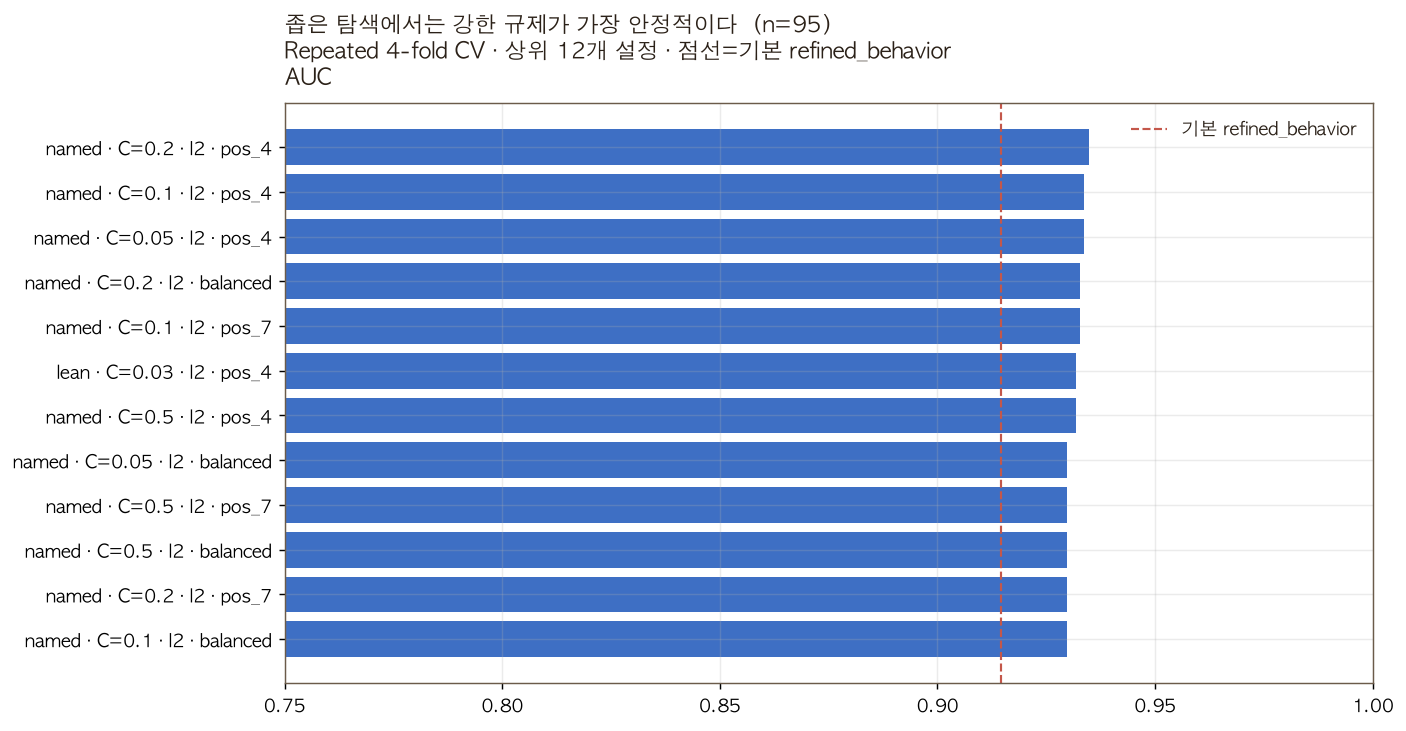

In [4]:
plot = grid_results.head(12).copy()
short_fs = {
    'lean_behavior': 'lean',
    'refined_behavior': 'refined',
    'refined_behavior_plus_named_events': 'named',
}
plot['label'] = plot.apply(
    lambda r: f"{short_fs.get(r.feature_set, r.feature_set)} · C={r.C} · {r.penalty} · {r.class_weight_name}",
    axis=1,
)
fig, ax = R.new(
    '좁은 탐색에서는 강한 규제가 가장 안정적이다',
    len(d),
    sub='Repeated 4-fold CV · 상위 12개 설정 · 점선=기본 refined_behavior',
    ylab='AUC',
    figsize=(10.8, 5.8),
)
plot = plot.sort_values('auc')
ax.barh(np.arange(len(plot)), plot.auc, color=R.PALETTE[1])
ax.axvline(float(base_refined['auc']), color=R.PALETTE[0], linestyle='--', linewidth=1.2, label='기본 refined_behavior')
ax.set_yticks(np.arange(len(plot)), plot.label)
ax.set_xlim(0.75, 1.0)
ax.legend(frameon=False)
chart_grid = R.save(fig, ax, 'g5_refined_hyperparam_grid_auc', zero_base=False)
print(R.check(chart_grid))
display(R.show(chart_grid))


## 3. Top 3 nested CV 재평가

grid 결과는 같은 데이터로 고른 값이라 낙관적일 수 있다. 상위 3개 후보만 바깥 CV에서 다시 평가한다.

In [5]:
top3_keys = grid_results.head(3)[['feature_set', 'C', 'penalty', 'class_weight_name']].to_dict(orient='records')
top3 = []
for row in top3_keys:
    cfg = next(g for g in grid if g['feature_set'] == row['feature_set'] and g['C'] == row['C'] and g['penalty'] == row['penalty'] and g['class_weight_name'] == row['class_weight_name'])
    top3.append(cfg)

outer = RepeatedStratifiedKFold(n_splits=4, n_repeats=20, random_state=231)
nested_pred_sum = np.zeros(len(y), dtype=float)
nested_pred_count = np.zeros(len(y), dtype=float)
selected_rows = []
inner_rank_rows = []
for fold, (tr, te) in enumerate(outer.split(d, y), start=1):
    train_df = d.iloc[tr].reset_index(drop=True)
    train_y = y[tr]
    test_df = d.iloc[te]
    best, inner_rank = inner_select(train_df, train_y, top3, n_splits=3)
    inner_rank['outer_fold'] = fold
    inner_rank_rows.append(inner_rank.drop(columns=['feature_cols', 'class_weight'], errors='ignore'))
    model = prep_model(best['feature_cols'], best['C'], best['penalty'], best['class_weight'])
    model.fit(train_df[best['feature_cols']], train_y)
    nested_pred_sum[te] += model.predict_proba(test_df[best['feature_cols']])[:, 1]
    nested_pred_count[te] += 1
    selected_rows.append({
        'outer_fold': fold,
        'feature_set': best['feature_set'],
        'C': best['C'],
        'penalty': best['penalty'],
        'class_weight_name': best['class_weight_name'],
        'inner_auc': best['auc'],
        'inner_pr_auc': best['pr_auc'],
    })

nested_pred = nested_pred_sum / nested_pred_count
nested_scores = score_predictions(y, nested_pred)
nested_scores['auc_ci_low'], nested_scores['auc_ci_high'] = bootstrap_ci(y, nested_pred, roc_auc_score)
nested_scores['pr_auc_ci_low'], nested_scores['pr_auc_ci_high'] = bootstrap_ci(y, nested_pred, average_precision_score)
selected = pd.DataFrame(selected_rows)
inner_all = pd.concat(inner_rank_rows, ignore_index=True)
selected.to_csv(OUT / 'nested_selected_configs.csv', index=False)
inner_all.to_csv(OUT / 'nested_inner_rankings.csv', index=False)
pd.DataFrame([nested_scores]).to_csv(OUT / 'nested_top3_eval_metrics.csv', index=False)
display(pd.DataFrame([nested_scores]))
display(selected.value_counts(['feature_set', 'C', 'penalty', 'class_weight_name']).reset_index(name='selected_folds'))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

...

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,auc,pr_auc,top30_cutoff,top30_flagged,top30_precision,top30_recall,top30_balanced_acc,auc_ci_low,auc_ci_high,pr_auc_ci_low,pr_auc_ci_high
0,0.927711,0.883704,0.285334,29,0.37931,0.916667,0.8499,0.782461,1.0,0.686667,1.0


,feature_set,C,penalty,class_weight_name,selected_folds
0,refined_behavior_plus_named_events,0.20,l2,pos_4,36
1,refined_behavior_plus_named_events,0.10,l2,pos_4,24
2,refined_behavior_plus_named_events,0.05,l2,pos_4,20


g5_refined_hyperparam_nested_selection.png  1298x631px


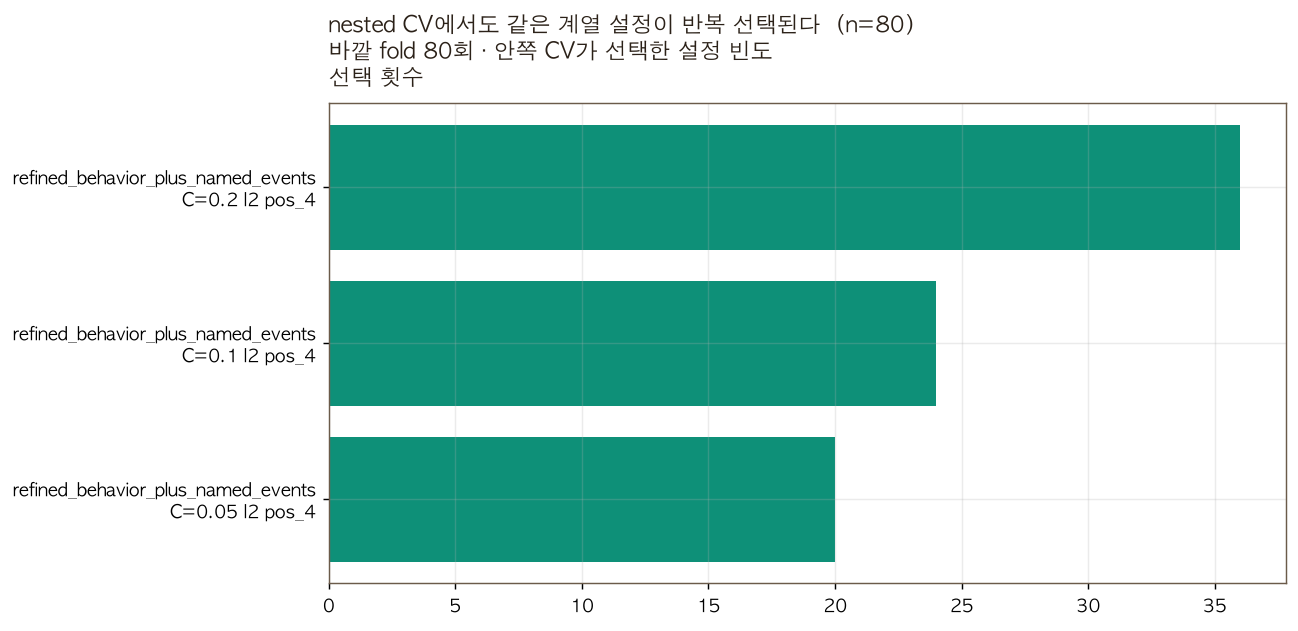

In [6]:
sel_counts = selected.value_counts(['feature_set', 'C', 'penalty', 'class_weight_name']).reset_index(name='selected_folds')
sel_counts['label'] = sel_counts.apply(lambda r: f"{r.feature_set}\nC={r.C} {r.penalty} {r.class_weight_name}", axis=1)
fig, ax = R.new(
    'nested CV에서도 같은 계열 설정이 반복 선택된다',
    len(selected),
    sub='바깥 fold 80회 · 안쪽 CV가 선택한 설정 빈도',
    ylab='선택 횟수',
    figsize=(9.5, 4.8),
)
sel_plot = sel_counts.sort_values('selected_folds')
ax.barh(np.arange(len(sel_plot)), sel_plot.selected_folds, color=R.PALETTE[2])
ax.set_yticks(np.arange(len(sel_plot)), sel_plot.label)
chart_nested = R.save(fig, ax, 'g5_refined_hyperparam_nested_selection', zero_base=True)
print(R.check(chart_nested))
display(R.show(chart_nested))


## 4. 계수 안정성

최종 후보 설정을 반복 CV fold마다 학습해 주요 계수의 중앙값과 10~90% 구간을 본다. 부호가 자주 뒤집히면 운영 설명에 쓰지 않는다.

In [7]:
best_row = grid_results.iloc[0].to_dict()
best_cfg = next(g for g in grid if g['feature_set'] == best_row['feature_set'] and g['C'] == best_row['C'] and g['penalty'] == best_row['penalty'] and g['class_weight_name'] == best_row['class_weight_name'])

coef_rows = []
cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=30, random_state=232)
for fold, (tr, te) in enumerate(cv.split(d, y), start=1):
    model = prep_model(best_cfg['feature_cols'], best_cfg['C'], best_cfg['penalty'], best_cfg['class_weight'])
    model.fit(d.iloc[tr][best_cfg['feature_cols']], y[tr])
    names = model.named_steps['prep'].get_feature_names_out()
    coefs = model.named_steps['clf'].coef_[0]
    for name, coef in zip(names, coefs):
        coef_rows.append({'fold': fold, 'feature': name.replace('num__', ''), 'coef': float(coef)})

coef_fold = pd.DataFrame(coef_rows)
coef_summary = coef_fold.groupby('feature', as_index=False).agg(
    median_coef=('coef', 'median'),
    q10=('coef', lambda s: float(np.percentile(s, 10))),
    q90=('coef', lambda s: float(np.percentile(s, 90))),
    positive_share=('coef', lambda s: float((s > 0).mean())),
)
coef_summary['abs_median'] = coef_summary.median_coef.abs()
coef_summary = coef_summary.sort_values('abs_median', ascending=False)
coef_fold.to_csv(OUT / 'best_config_fold_coefficients.csv', index=False)
coef_summary.to_csv(OUT / 'best_config_coefficient_stability.csv', index=False)
display(coef_summary.head(18))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,feature,median_coef,q10,q90,positive_share,abs_median
16,log_early_ga_auto_events,0.626861,0.461133,0.836435,1.000000,0.626861
27,log_early_zone_enter_events,0.433639,0.331135,0.526446,1.000000,0.433639
17,log_early_mine_ore_events,0.409062,0.304961,0.485081,1.000000,0.409062
15,log_early_fishing_sea_events,0.375725,0.202521,0.468882,1.000000,0.375725
24,log_early_session_time_events,0.367155,0.193360,0.499652,1.000000,0.367155
9,log_early_connect_fail_events,-0.366935,-0.461788,-0.231873,0.000000,0.366935
5,log_early_advanced_events,0.348914,0.234535,0.440968,1.000000,0.348914
1,entry_auth_share,0.342631,-0.104475,0.414510,0.750000,0.342631
13,log_early_entry_auth_events,0.321568,0.215829,0.417961,1.000000,0.321568
12,log_early_econ_tx_events,0.274530,0.046706,0.361999,0.950000,0.274530


g5_refined_hyperparam_coef_stability.png  1275x731px


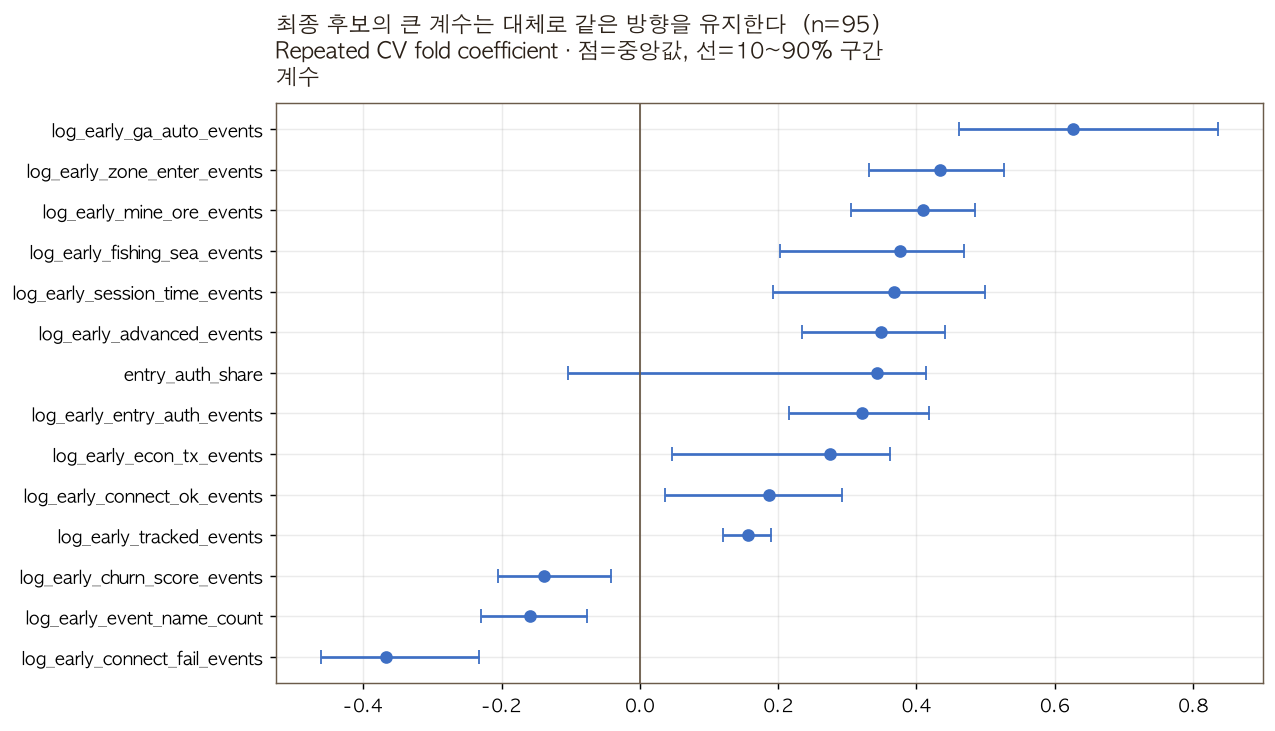

In [8]:
coef_plot = coef_summary.head(14).sort_values('median_coef')
fig, ax = R.new(
    '최종 후보의 큰 계수는 대체로 같은 방향을 유지한다',
    len(d),
    sub='Repeated CV fold coefficient · 점=중앙값, 선=10~90% 구간',
    ylab='계수',
    figsize=(9.8, 5.8),
)
ypos = np.arange(len(coef_plot))
ax.errorbar(
    coef_plot.median_coef,
    ypos,
    xerr=[coef_plot.median_coef - coef_plot.q10, coef_plot.q90 - coef_plot.median_coef],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.axvline(0, color=R.MUTED, linewidth=1)
ax.set_yticks(ypos, coef_plot.feature)
chart_coef = R.save(fig, ax, 'g5_refined_hyperparam_coef_stability', zero_base=False)
print(R.check(chart_coef))
display(R.show(chart_coef))


## 5. 판정과 저장 config

grid 1위는 추천 후보지만, 운영 threshold 확정은 아니다. 지금은 `model_version`, 피처 목록, preprocessing, penalty/C/class_weight만 재현 가능하게 저장한다.

In [9]:
best_key = f"{best_cfg['feature_set']}|C={best_cfg['C']}|{best_cfg['penalty']}|{best_cfg['class_weight_name']}"
best_pred = preds[best_key]
best_scores = score_predictions(y, best_pred)
best_scores['auc_ci_low'], best_scores['auc_ci_high'] = bootstrap_ci(y, best_pred, roc_auc_score)
best_scores['pr_auc_ci_low'], best_scores['pr_auc_ci_high'] = bootstrap_ci(y, best_pred, average_precision_score)

baseline_pr = float(base_refined['pr_auc'])
baseline_auc = float(base_refined['auc'])
verdict = '채택 후보' if (
    best_scores['auc'] >= baseline_auc
    and best_scores['pr_auc'] >= baseline_pr * 0.95
    and best_scores['top30_recall'] >= 0.80
    and nested_scores['auc'] >= 0.85
) else '보류'

config = {
    'model_version': 'g5-refined-logistic-grid-2026-09-15',
    'verdict': verdict,
    'sample': {'devices': int(len(d)), 'positives': int(y.sum()), 'positive_rate': float(y.mean())},
    'target': 'later_active: 10m-24h deliberate action after first observed event',
    'excluded': 'GA4 ab_variant beta_A/beta_B marked devices',
    'not_used': ['A/B variant effect', 'later_* columns as features', 'raw identifiers', 'XGBoost/LightGBM'],
    'selected_config': {
        'feature_set': best_cfg['feature_set'],
        'features': best_cfg['feature_cols'],
        'C': best_cfg['C'],
        'penalty': best_cfg['penalty'],
        'class_weight_name': best_cfg['class_weight_name'],
        'class_weight': best_cfg['class_weight'],
        'solver': 'liblinear',
        'scaler': 'StandardScaler',
        'numeric_imputer': 'median',
    },
    'same_cv_scores': best_scores,
    'nested_top3_scores': nested_scores,
    'baseline_refined_behavior': {
        'auc': baseline_auc,
        'pr_auc': baseline_pr,
    },
    'criteria': {
        'auc_gte_baseline': best_scores['auc'] >= baseline_auc,
        'pr_auc_gte_95pct_baseline': best_scores['pr_auc'] >= baseline_pr * 0.95,
        'top30_recall_gte_80pct': best_scores['top30_recall'] >= 0.80,
        'nested_auc_gte_85pct': nested_scores['auc'] >= 0.85,
    },
}
with open(OUT / 'selected_hyperparams.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

score_df = d[['device_label', 'split_segment', 'channel_segment', 'early_tracked_events', 'early_actions', 'deliberate_share', 'later_active']].copy()
score_df['best_grid_score'] = best_pred
score_df['nested_top3_score'] = nested_pred
score_df.to_csv(OUT / 'hyperparam_scores.csv', index=False)

display(pd.DataFrame([{
    'verdict': verdict,
    'feature_set': best_cfg['feature_set'],
    'C': best_cfg['C'],
    'penalty': best_cfg['penalty'],
    'class_weight': best_cfg['class_weight_name'],
    **best_scores,
    'nested_auc': nested_scores['auc'],
    'nested_pr_auc': nested_scores['pr_auc'],
}]))
print(json.dumps(config, ensure_ascii=False, indent=2)[:2600])


,verdict,feature_set,C,penalty,class_weight,auc,pr_auc,top30_cutoff,top30_flagged,top30_precision,top30_recall,top30_balanced_acc,auc_ci_low,auc_ci_high,pr_auc_ci_low,pr_auc_ci_high,nested_auc,nested_pr_auc
0,채택 후보,refined_behavior_plus_named_events,0.2,l2,pos_4,0.934739,0.874508,0.232102,29,0.37931,0.916667,0.8499,0.810309,1.0,0.679212,1.0,0.927711,0.883704


{
  "model_version": "g5-refined-logistic-grid-2026-09-15",
  "verdict": "채택 후보",
  "sample": {
    "devices": 95,
    "positives": 12,
    "positive_rate": 0.12631578947368421
  },
  "target": "later_active: 10m-24h deliberate action after first observed event",
  "excluded": "GA4 ab_variant beta_A/beta_B marked devices",
  "not_used": [
    "A/B variant effect",
    "later_* columns as features",
    "raw identifiers",
    "XGBoost/LightGBM"
  ],
  "selected_config": {
    "feature_set": "refined_behavior_plus_named_events",
    "features": [
      "log_early_tracked_events",
      "log_early_actions",
      "deliberate_share",
      "log_early_action_kinds",
      "log_early_area_count",
      "log_early_event_name_count",
      "log_early_ga_auto_events",
      "log_early_entry_auth_events",
      "log_early_connect_ok_events",
      "log_early_connect_fail_events",
      "log_early_other_tracking_events",
      "ga_auto_share",
      "entry_auth_share",
      "other_tracking_share

**이 숫자로 말할 수 없는 것:** grid 결과는 표본 95대/양성 12대에서 나온다. nested CV를 붙였지만, 같은 기간의 시설 업데이트·유입·채널 변화가 섞여 있어 미래 데이터 성능을 보장하지 않는다. 계수 부호가 안정적인 피처만 제품 설명에 쓰고, threshold는 며칠 뒤 재실행 전까지 확정하지 않는다.

**다음에 확인할 것:** 같은 feature SQL을 새 완전 일자까지 확장해 재실행한다. 선택 config가 유지되고 top 30% recall/precision이 무너지지 않으면 G6 적용 설계로 넘어간다.